# BeetleCast 06 — Final 2025 deployment

This notebook produces the operational BeetleCast output:

> **A 2025 forest inspection-priority map generated entirely from information available through 2024.**

It preserves the historical validation from notebooks 03–05 and then:

1. trains the selected model on all stable-forest 2022–2023 samples;
2. creates 2025 predictor features from Sentinel-2 and AlphaEarth history through 2024;
3. applies the historical LULC stable-forest mask through 2024;
4. exports a 2025 risk GeoTIFF and top inspection patches;
5. displays the prediction beside the observed 2025 Sentinel-2 image;
6. searches for genuine 2025 bark-beetle labels.

**Important:** the observed 2025 RGB image is for visual comparison only.  
Without independent 2025 damage labels, it cannot provide PR-AUC or ROC-AUC validation.


In [1]:
from pathlib import Path
import json
import re
import warnings

import joblib
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xarray as xr
import rasterio
import rioxarray

from affine import Affine
from pyproj import CRS
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.transform import from_origin
from rasterio.vrt import WarpedVRT
from rasterio.windows import Window, bounds as window_bounds
from shapely.geometry import box

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

PREDICTION_YEAR = 2025
LATEST_INPUT_YEAR = PREDICTION_YEAR - 1
PRIOR_INPUT_YEAR = PREDICTION_YEAR - 2

RANDOM_STATE = 42
PATCH_PIXELS = 5
MIN_HISTORY_YEAR = 2018

LATEST_FOREST_MIN = 0.50
FOREST_PERSISTENCE_MIN = 0.80

cwd = Path.cwd()
if (cwd / "hackathon_data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "hackathon_data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not find hackathon_data/. Launch Jupyter from project_root."
    )

RAW_ROOT = PROJECT_ROOT / "hackathon_data" / "raw"
PROCESSED_ROOT = PROJECT_ROOT / "hackathon_data" / "processed"
LULC_OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "lulc"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "deployment_2025"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print(
    f"Prediction target: {PREDICTION_YEAR}; "
    f"latest predictor year: {LATEST_INPUT_YEAR}"
)


PROJECT_ROOT: /Users/hemat/Desktop/hackathon-demo
OUTPUT_ROOT: /Users/hemat/Desktop/hackathon-demo/outputs/deployment_2025
Prediction target: 2025; latest predictor year: 2024


## 1. Load the validated stable-forest training table

The final model uses the selected feature set:

- 12 Sentinel-2 temporal features;
- 320 temporal AlphaEarth features;
- LULC only as a stable-forest mask, not as a classifier feature.


In [2]:
training_path = (
    LULC_OUTPUT_ROOT
    / "beetlecast_training_table_with_lulc.csv"
)

assert training_path.exists(), (
    "Missing outputs/lulc/beetlecast_training_table_with_lulc.csv. "
    "Run notebooks 01, 03, and 04 first."
)

training = pd.read_csv(training_path)

baseline_features = [
    "ndvi_recent",
    "ndre_recent",
    "nbr_recent",
    "ndvi_prior",
    "ndre_prior",
    "nbr_prior",
    "ndvi_change",
    "ndre_change",
    "nbr_change",
    "ndvi_std",
    "ndre_std",
    "valid_fraction",
]

temporal_aef_features = sorted([
    column for column in training.columns
    if column.startswith("aef_")
])

model_features = baseline_features + temporal_aef_features

if training["stable_forest"].dtype == object:
    training["stable_forest"] = (
        training["stable_forest"]
        .astype(str)
        .str.lower()
        .eq("true")
    )

final_training = training[
    training["stable_forest"]
].dropna(
    subset=model_features + ["target"]
).copy()

assert final_training["target"].nunique() == 2
assert len(temporal_aef_features) > 0

print("Training rows:", len(final_training))
print("Sentinel-2 features:", len(baseline_features))
print("Temporal AEF features:", len(temporal_aef_features))
print("Total model features:", len(model_features))
print(final_training.groupby(["label_year", "target"]).size())


Training rows: 16092
Sentinel-2 features: 12
Temporal AEF features: 320
Total model features: 332
label_year  target
2022        0         5824
            1         2103
2023        0         6139
            1         2026
dtype: int64


## 2. Train the final model on all validated samples

Historical performance is reported by notebooks 03 and 04.  
This deployment model is fitted on all eligible labelled samples because its purpose is to generate the strongest 2025 map.


In [3]:
final_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=350,
    max_leaf_nodes=31,
    min_samples_leaf=25,
    l2_regularization=2.0,
    random_state=RANDOM_STATE,
)

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=final_training["target"].astype(int),
)

final_model.fit(
    final_training[model_features],
    final_training["target"].astype(int),
    sample_weight=sample_weights,
)

model_path = OUTPUT_ROOT / "beetlecast_2025_model.joblib"
joblib.dump(
    {
        "model": final_model,
        "feature_names": model_features,
        "prediction_year": PREDICTION_YEAR,
        "latest_input_year": LATEST_INPUT_YEAR,
    },
    model_path,
)

print("Final model fitted.")
print("Saved:", model_path)


Final model fitted.
Saved: /Users/hemat/Desktop/hackathon-demo/outputs/deployment_2025/beetlecast_2025_model.joblib


## 3. Open the Sentinel-2 cube and reconstruct its grid

In [4]:
zarr_paths = list(RAW_ROOT.rglob("cube.zarr"))
f3_candidates = [
    path for path in zarr_paths
    if (
        "f3" in str(path).lower()
        or "bark" in str(path).lower()
        or "germany" in str(path).lower()
    )
]

assert f3_candidates or zarr_paths, (
    "No Sentinel-2 cube.zarr found under hackathon_data/raw/"
)

CUBE_PATH = (f3_candidates or zarr_paths)[0]
ds = xr.open_zarr(CUBE_PATH, chunks="auto")

if float(ds.y.values[0]) < float(ds.y.values[-1]):
    ds = ds.sortby("y", ascending=False)

required_bands = {"B02", "B03", "B04", "B05", "B08", "B12"}
missing_bands = required_bands - set(ds.data_vars)
assert not missing_bands, f"Missing Sentinel-2 bands: {missing_bands}"

x = np.asarray(ds.x.values)
y = np.asarray(ds.y.values)

dx = float(abs(x[1] - x[0]))
dy = float(abs(y[1] - y[0]))

left = float(x.min() - dx / 2)
top = float(y.max() + dy / 2)

base_transform = from_origin(left, top, dx, dy)
patch_transform = base_transform * Affine.scale(
    PATCH_PIXELS,
    PATCH_PIXELS,
)

base_height = ds.sizes["y"]
base_width = ds.sizes["x"]
patch_height = base_height // PATCH_PIXELS
patch_width = base_width // PATCH_PIXELS

trimmed_height = patch_height * PATCH_PIXELS
trimmed_width = patch_width * PATCH_PIXELS

right = left + trimmed_width * dx
bottom = top - trimmed_height * dy
map_extent = [left, right, bottom, top]

def infer_cube_crs(dataset):
    try:
        if dataset.rio.crs is not None:
            return CRS.from_user_input(dataset.rio.crs)
    except Exception:
        pass

    if "spatial_ref" in dataset:
        attrs = dataset["spatial_ref"].attrs
        for key in ("crs_wkt", "spatial_ref", "wkt"):
            value = attrs.get(key)
            if value:
                return CRS.from_user_input(value)

    raise ValueError("Could not infer the Sentinel-2 CRS")

grid_crs = infer_cube_crs(ds)

available_years = sorted(
    set(pd.DatetimeIndex(ds.time.values).year)
)

print("Cube:", CUBE_PATH)
print("Available Sentinel-2 years:", available_years)
print("Patch grid:", patch_height, "x", patch_width)
print("CRS:", grid_crs)

for needed_year in [
    PRIOR_INPUT_YEAR,
    LATEST_INPUT_YEAR,
    PREDICTION_YEAR,
]:
    assert needed_year in available_years, (
        f"Sentinel-2 year {needed_year} is missing from the cube."
    )


Cube: /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/sentinal2/sentinel2/F3_Germany_BarkBeetle/2017-01-01_2025-12-31/cube.zarr
Available Sentinel-2 years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Patch grid: 252 x 213
CRS: PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32632"]]


## 4. Build the 2025 Sentinel-2 predictor features

For the 2025 map:

- `recent` = 2024;
- `prior` = 2023;
- the 2025 image itself is not used as a predictor.


In [5]:
def clean_reflectance(dataset, band):
    values = dataset[band].astype("float32")

    if "n_obs" in dataset:
        values = values.where(dataset["n_obs"] > 0)

    cutoff = np.datetime64("2022-01-25")
    values = xr.where(
        dataset.time >= cutoff,
        xr.where(values >= 1000, values - 1000, 0),
        values,
    )

    return values / 10000.0

red = clean_reflectance(ds, "B04")
red_edge = clean_reflectance(ds, "B05")
nir = clean_reflectance(ds, "B08")
swir2 = clean_reflectance(ds, "B12")

ndvi = (nir - red) / (nir + red)
ndre = (nir - red_edge) / (nir + red_edge)
nbr = (nir - swir2) / (nir + swir2)

def year_subset(array, year, name):
    result = array.sel(
        time=slice(f"{year}-01-01", f"{year}-12-31")
    )
    if result.sizes.get("time", 0) == 0:
        raise ValueError(f"No observations for {name} in {year}")
    return result

recent_ndvi = year_subset(ndvi, LATEST_INPUT_YEAR, "NDVI")
recent_ndre = year_subset(ndre, LATEST_INPUT_YEAR, "NDRE")
recent_nbr = year_subset(nbr, LATEST_INPUT_YEAR, "NBR")

prior_ndvi = year_subset(ndvi, PRIOR_INPUT_YEAR, "NDVI")
prior_ndre = year_subset(ndre, PRIOR_INPUT_YEAR, "NDRE")
prior_nbr = year_subset(nbr, PRIOR_INPUT_YEAR, "NBR")

recent_valid = xr.where(
    np.isfinite(recent_ndvi),
    1.0,
    0.0,
).mean("time")

s2_features = xr.Dataset({
    "ndvi_recent": recent_ndvi.median("time", skipna=True),
    "ndre_recent": recent_ndre.median("time", skipna=True),
    "nbr_recent": recent_nbr.median("time", skipna=True),
    "ndvi_prior": prior_ndvi.median("time", skipna=True),
    "ndre_prior": prior_ndre.median("time", skipna=True),
    "nbr_prior": prior_nbr.median("time", skipna=True),
    "ndvi_change": (
        recent_ndvi.median("time", skipna=True)
        - prior_ndvi.median("time", skipna=True)
    ),
    "ndre_change": (
        recent_ndre.median("time", skipna=True)
        - prior_ndre.median("time", skipna=True)
    ),
    "nbr_change": (
        recent_nbr.median("time", skipna=True)
        - prior_nbr.median("time", skipna=True)
    ),
    "ndvi_std": recent_ndvi.std("time", skipna=True),
    "ndre_std": recent_ndre.std("time", skipna=True),
    "valid_fraction": recent_valid,
}).coarsen(
    y=PATCH_PIXELS,
    x=PATCH_PIXELS,
    boundary="trim",
).mean(skipna=True).compute()

print(s2_features)


<xarray.Dataset> Size: 3MB
Dimensions:         (y: 252, x: 213)
Coordinates:
  * y               (y) float64 2kB 5.512e+06 5.512e+06 ... 5.5e+06 5.499e+06
  * x               (x) float64 2kB 3.546e+05 3.547e+05 ... 3.652e+05 3.652e+05
    spatial_ref     int64 8B 0
Data variables:
    ndvi_recent     (y, x) float32 215kB nan nan nan nan nan ... nan nan nan nan
    ndre_recent     (y, x) float32 215kB nan nan nan nan nan ... nan nan nan nan
    nbr_recent      (y, x) float32 215kB nan nan nan nan nan ... nan nan nan nan
    ndvi_prior      (y, x) float32 215kB nan nan nan nan nan ... nan nan nan nan
    ndre_prior      (y, x) float32 215kB nan nan nan nan nan ... nan nan nan nan
    nbr_prior       (y, x) float32 215kB nan nan nan nan nan ... nan nan nan nan
    ndvi_change     (y, x) float32 215kB nan nan nan nan nan ... nan nan nan nan
    ndre_change     (y, x) float32 215kB nan nan nan nan nan ... nan nan nan nan
    nbr_change      (y, x) float32 215kB nan nan nan nan nan ... nan n

## 5. Build temporal AlphaEarth features through 2024

The 2025 deployment uses AEF history from 2018–2024:

- latest value;
- historical mean;
- historical standard deviation;
- 2024 minus 2023 change;
- 2024 minus 2018 change.


In [6]:
def infer_year(path):
    match = re.search(
        r"(20(?:1[7-9]|2[0-5]))",
        path.name,
    )
    return int(match.group(1)) if match else None

aef_tifs = [
    path for path in RAW_ROOT.rglob("*.tif")
    if (
        "aef" in str(path).lower()
        or "alphaearth" in str(path).lower()
        or "embedding" in str(path).lower()
    )
]

assert aef_tifs, "No AlphaEarth TIFFs found."

aef_by_year = {}
for path in aef_tifs:
    year = infer_year(path)
    if year is not None:
        aef_by_year.setdefault(year, []).append(path)

required_aef_years = set(
    range(MIN_HISTORY_YEAR, LATEST_INPUT_YEAR + 1)
)
missing_aef_years = sorted(
    required_aef_years - set(aef_by_year)
)
assert not missing_aef_years, (
    f"Missing AlphaEarth years: {missing_aef_years}"
)

selected_aef = {
    year: sorted(aef_by_year[year])[0]
    for year in sorted(required_aef_years)
}

for year, path in selected_aef.items():
    print(year, "->", path)

def read_aef_on_patch_grid(path):
    with rasterio.open(path) as src:
        with WarpedVRT(
            src,
            crs=grid_crs,
            transform=patch_transform,
            width=patch_width,
            height=patch_height,
            resampling=Resampling.bilinear,
            nodata=np.nan,
        ) as vrt:
            return (
                vrt.read(masked=True)
                .filled(np.nan)
                .astype("float32")
            )

aef_arrays = {
    year: read_aef_on_patch_grid(path)
    for year, path in selected_aef.items()
}

band_counts = {
    year: values.shape[0]
    for year, values in aef_arrays.items()
}
assert len(set(band_counts.values())) == 1, (
    f"AlphaEarth band counts differ: {band_counts}"
)

N_AEF_BANDS = next(iter(band_counts.values()))
assert len(temporal_aef_features) == N_AEF_BANDS * 5, (
    "Deployment AEF feature count does not match the training table."
)

aef_stack = np.stack(
    [aef_arrays[year] for year in sorted(aef_arrays)],
    axis=0,
)

aef_latest = aef_stack[-1]
aef_mean = np.nanmean(aef_stack, axis=0)
aef_std = np.nanstd(aef_stack, axis=0)
aef_recent_change = aef_stack[-1] - aef_stack[-2]
aef_long_change = aef_stack[-1] - aef_stack[0]

print("AEF history shape:", aef_stack.shape)
print("AEF bands:", N_AEF_BANDS)


2018 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2018.tif
2019 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2019.tif
2020 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2020.tif
2021 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2021.tif
2022 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2022.tif
2023 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2023.tif
2024 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2024.tif
AEF history shape: (7, 64, 252, 213)
AEF bands: 64


## 6. Build the stable-forest mask from LULC through 2024

The model is deployed only where the land was persistently classified as forest before 2025.


In [7]:
lulc_tifs = [
    path for path in RAW_ROOT.rglob("*.tif")
    if (
        "lulc" in str(path).lower()
        or "landcover" in str(path).lower()
        or "land_cover" in str(path).lower()
    )
]

assert lulc_tifs, "No ESRI LULC TIFFs found."

lulc_by_year = {}
for path in lulc_tifs:
    year = infer_year(path)
    if year is not None:
        lulc_by_year.setdefault(year, []).append(path)

required_lulc_years = set(
    range(MIN_HISTORY_YEAR, LATEST_INPUT_YEAR + 1)
)
missing_lulc_years = sorted(
    required_lulc_years - set(lulc_by_year)
)
assert not missing_lulc_years, (
    f"Missing LULC years: {missing_lulc_years}"
)

selected_lulc = {
    year: sorted(lulc_by_year[year])[0]
    for year in sorted(required_lulc_years)
}

class_jsons = [
    path for path in RAW_ROOT.rglob("*.json")
    if "lulc" in path.name.lower()
    or "landcover" in path.name.lower()
]

def collect_code_name_pairs(obj):
    pairs = []

    if isinstance(obj, dict):
        for key, value in obj.items():
            if isinstance(value, str):
                try:
                    pairs.append((int(key), value))
                except Exception:
                    pass

            if isinstance(value, dict):
                code = (
                    value.get("value")
                    or value.get("code")
                    or value.get("id")
                    or value.get("class_id")
                )
                name = (
                    value.get("name")
                    or value.get("label")
                    or value.get("class_name")
                    or value.get("description")
                )
                if code is not None and name is not None:
                    try:
                        pairs.append((int(code), str(name)))
                    except Exception:
                        pass

            pairs.extend(collect_code_name_pairs(value))

    elif isinstance(obj, list):
        for item in obj:
            pairs.extend(collect_code_name_pairs(item))

    return pairs

class_pairs = []
for path in class_jsons:
    try:
        with open(path, "r") as handle:
            class_pairs.extend(
                collect_code_name_pairs(json.load(handle))
            )
    except Exception:
        pass

forest_codes = sorted({
    code for code, name in set(class_pairs)
    if (
        "tree" in name.lower()
        or "forest" in name.lower()
    )
})

if not forest_codes:
    forest_codes = [2]
    print(
        "WARNING: Could not infer the Trees class. "
        "Using the common ESRI Trees code 2."
    )

print("Forest class code(s):", forest_codes)

def read_forest_fraction(path):
    with rasterio.open(path) as src:
        with WarpedVRT(
            src,
            crs=grid_crs,
            transform=base_transform,
            width=base_width,
            height=base_height,
            resampling=Resampling.nearest,
            nodata=0,
        ) as vrt:
            values = (
                vrt.read(1, masked=True)
                .filled(0)
            )

    forest = np.isin(
        values,
        forest_codes,
    ).astype("float32")

    forest = forest[
        :trimmed_height,
        :trimmed_width,
    ]

    return forest.reshape(
        patch_height,
        PATCH_PIXELS,
        patch_width,
        PATCH_PIXELS,
    ).mean(axis=(1, 3))

forest_history = np.stack([
    read_forest_fraction(selected_lulc[year])
    for year in sorted(selected_lulc)
])

latest_forest_fraction = forest_history[-1]
forest_persistence = forest_history.mean(axis=0)

stable_forest_mask = (
    (latest_forest_fraction >= LATEST_FOREST_MIN)
    & (forest_persistence >= FOREST_PERSISTENCE_MIN)
)

print(
    "Stable-forest patches:",
    int(stable_forest_mask.sum()),
)


Forest class code(s): [2]
Stable-forest patches: 29809


## 7. Restrict the prediction to the F3 AOI

In [8]:
aoi_candidates = [
    path for path in PROJECT_ROOT.rglob("*.geojson")
    if (
        "aoi" in path.name.lower()
        and (
            "f3" in path.name.lower()
            or "germany" in path.name.lower()
            or "bark" in path.name.lower()
        )
    )
]

assert aoi_candidates, (
    "Could not find the F3 AOI GeoJSON."
)

AOI_PATH = aoi_candidates[0]
aoi = gpd.read_file(AOI_PATH)

if aoi.crs is None:
    raise ValueError("The AOI file has no CRS.")

aoi_grid = aoi.to_crs(grid_crs)
aoi_geometry = aoi_grid.geometry.union_all()

aoi_mask = rasterize(
    [(aoi_geometry, 1)],
    out_shape=(patch_height, patch_width),
    transform=patch_transform,
    fill=0,
    default_value=1,
    dtype="uint8",
    all_touched=True,
).astype(bool)

print("AOI:", AOI_PATH)
print("AOI patches:", int(aoi_mask.sum()))


AOI: /Users/hemat/Desktop/hackathon-demo/hackathon_data/clean/F3_bark_beetle_labels_in_aoi.geojson
AOI patches: 5237


## 8. Assemble all eligible 2025 patch features and predict risk


In [9]:
s2_valid = np.ones(
    (patch_height, patch_width),
    dtype=bool,
)

for feature in baseline_features:
    s2_valid &= np.isfinite(
        s2_features[feature].values
    )

aef_valid = (
    np.all(np.isfinite(aef_latest), axis=0)
    & np.all(np.isfinite(aef_mean), axis=0)
    & np.all(np.isfinite(aef_std), axis=0)
    & np.all(np.isfinite(aef_recent_change), axis=0)
    & np.all(np.isfinite(aef_long_change), axis=0)
)

eligible_mask = (
    aoi_mask
    & stable_forest_mask
    & s2_valid
    & aef_valid
    & (s2_features["valid_fraction"].values >= 0.25)
)

rows, cols = np.where(eligible_mask)
assert len(rows) > 0, "No eligible 2025 patches found."

deployment = pd.DataFrame({
    "patch_row": rows,
    "patch_col": cols,
})

for feature in baseline_features:
    deployment[feature] = (
        s2_features[feature].values[rows, cols]
    )

for band_index in range(N_AEF_BANDS):
    band = band_index + 1

    deployment[
        f"aef_latest_{band:02d}"
    ] = aef_latest[band_index, rows, cols]

    deployment[
        f"aef_mean_{band:02d}"
    ] = aef_mean[band_index, rows, cols]

    deployment[
        f"aef_std_{band:02d}"
    ] = aef_std[band_index, rows, cols]

    deployment[
        f"aef_recent_change_{band:02d}"
    ] = aef_recent_change[band_index, rows, cols]

    deployment[
        f"aef_long_change_{band:02d}"
    ] = aef_long_change[band_index, rows, cols]

missing_deployment_features = (
    set(model_features) - set(deployment.columns)
)
assert not missing_deployment_features, (
    f"Missing deployment features: "
    f"{missing_deployment_features}"
)

deployment["predicted_risk"] = final_model.predict_proba(
    deployment[model_features]
)[:, 1].astype("float32")

risk_grid = np.full(
    (patch_height, patch_width),
    np.nan,
    dtype="float32",
)
risk_grid[rows, cols] = deployment["predicted_risk"]

print("Predicted patches:", len(deployment))
print(
    deployment["predicted_risk"]
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
)


Predicted patches: 3041
count    3041.000000
mean        0.545959
std         0.259395
min         0.002173
50%         0.586585
90%         0.859785
95%         0.896590
99%         0.952585
max         0.986554
Name: predicted_risk, dtype: float64


## 9. Export the 2025 risk map and inspection zones

In [10]:
risk_tif = OUTPUT_ROOT / "beetlecast_2025_risk.tif"

with rasterio.open(
    risk_tif,
    "w",
    driver="GTiff",
    height=patch_height,
    width=patch_width,
    count=1,
    dtype="float32",
    crs=grid_crs,
    transform=patch_transform,
    nodata=np.nan,
    compress="deflate",
) as destination:
    destination.write(risk_grid, 1)

deployment_path = (
    OUTPUT_ROOT
    / "beetlecast_2025_patch_predictions.csv"
)
deployment.to_csv(deployment_path, index=False)

top_10_percent_threshold = deployment[
    "predicted_risk"
].quantile(0.90)

top_10_percent_mask = (
    np.isfinite(risk_grid)
    & (risk_grid >= top_10_percent_threshold)
)

top_10_patches = deployment.nlargest(
    10,
    "predicted_risk",
).copy()

top_records = []
for row in top_10_patches.itertuples(index=False):
    left_b, bottom_b, right_b, top_b = window_bounds(
        Window(
            int(row.patch_col),
            int(row.patch_row),
            1,
            1,
        ),
        patch_transform,
    )

    top_records.append({
        "rank": len(top_records) + 1,
        "predicted_risk": float(row.predicted_risk),
        "geometry": box(
            left_b,
            bottom_b,
            right_b,
            top_b,
        ),
    })

top_zones = gpd.GeoDataFrame(
    top_records,
    crs=grid_crs,
)

top_zones_path = (
    OUTPUT_ROOT
    / "beetlecast_2025_top10_inspection_patches.gpkg"
)

top_zones.to_file(
    top_zones_path,
    layer="top10_inspection_patches",
    driver="GPKG",
)

print("Saved:", risk_tif)
print("Saved:", deployment_path)
print("Saved:", top_zones_path)
print(
    "Highest-risk 10% threshold:",
    round(float(top_10_percent_threshold), 3),
)


Saved: /Users/hemat/Desktop/hackathon-demo/outputs/deployment_2025/beetlecast_2025_risk.tif
Saved: /Users/hemat/Desktop/hackathon-demo/outputs/deployment_2025/beetlecast_2025_patch_predictions.csv
Saved: /Users/hemat/Desktop/hackathon-demo/outputs/deployment_2025/beetlecast_2025_top10_inspection_patches.gpkg
Highest-risk 10% threshold: 0.86


## 10. Build the observed 2025 Sentinel-2 image

This image is not fed into the predictor. It is displayed next to the risk map for visual inspection.


In [11]:
def make_annual_rgb(year):
    channels = []

    for band in ["B04", "B03", "B02"]:
        reflectance = clean_reflectance(ds, band)
        annual = year_subset(
            reflectance,
            year,
            f"{band} RGB",
        )
        median = annual.median(
            "time",
            skipna=True,
        ).compute().values

        channels.append(
            median[
                :trimmed_height,
                :trimmed_width,
            ]
        )

    return np.stack(channels, axis=-1)

def stretch_rgb(rgb, mask=None):
    result = np.zeros_like(
        rgb,
        dtype="float32",
    )

    for channel in range(3):
        values = rgb[..., channel]

        if mask is None:
            sample = values[np.isfinite(values)]
        else:
            sample = values[
                mask & np.isfinite(values)
            ]

        if sample.size == 0:
            continue

        low, high = np.nanpercentile(
            sample,
            [2, 98],
        )

        if high <= low:
            high = low + 1e-6

        result[..., channel] = np.clip(
            (values - low) / (high - low),
            0,
            1,
        )

    return result

rgb_2025 = make_annual_rgb(PREDICTION_YEAR)

aoi_base_mask = rasterize(
    [(aoi_geometry, 1)],
    out_shape=(trimmed_height, trimmed_width),
    transform=base_transform,
    fill=0,
    default_value=1,
    dtype="uint8",
    all_touched=True,
).astype(bool)

rgb_2025 = stretch_rgb(
    rgb_2025,
    mask=aoi_base_mask,
)

rgb_2025[~aoi_base_mask] = np.nan

print("2025 RGB prepared:", rgb_2025.shape)


2025 RGB prepared: (1260, 1065, 3)


## 11. Search for genuine 2025 bark-beetle labels

The notebook does not treat the 2025 RGB image as ground truth.  
It only overlays 2025 polygons when a genuine labelled file is available.


In [12]:
def extract_label_years(frame):
    if "label_year" in frame.columns:
        return pd.to_numeric(
            frame["label_year"],
            errors="coerce",
        )

    filename_columns = [
        column for column in frame.columns
        if (
            "tile" in column.lower()
            or "file" in column.lower()
            or "name" in column.lower()
            or "year" in column.lower()
        )
    ]

    for column in filename_columns:
        years = pd.to_numeric(
            frame[column]
            .astype(str)
            .str.extract(r"(20\d{2})")[0],
            errors="coerce",
        )
        if years.notna().any():
            return years

    return pd.Series(
        np.nan,
        index=frame.index,
    )

label_candidates = [
    path for path in PROJECT_ROOT.rglob("*")
    if (
        path.is_file()
        and path.suffix.lower() in {
            ".gpkg",
            ".geojson",
            ".shp",
        }
        and "aoi" not in path.name.lower()
        and (
            "beetle" in path.name.lower()
            or "bettle" in path.name.lower()
            or "damage" in path.name.lower()
        )
    )
]

labels_2025 = None
labels_2025_source = None

for path in label_candidates:
    try:
        frame = gpd.read_file(path)

        if frame.empty or frame.crs is None:
            continue

        years = extract_label_years(frame)
        candidate = frame[
            years == PREDICTION_YEAR
        ].copy()

        if not candidate.empty:
            candidate["label_year"] = PREDICTION_YEAR
            labels_2025 = candidate.to_crs(grid_crs)
            labels_2025_source = path
            break
    except Exception:
        continue

if labels_2025 is None:
    print(
        "No independent 2025 bark-beetle labels were found.\n"
        "The 2025 map can be inspected visually, but PR-AUC, "
        "ROC-AUC, and true capture cannot be calculated."
    )
else:
    print(
        "Found 2025 labels:",
        labels_2025_source,
    )
    print("2025 polygons:", len(labels_2025))


No independent 2025 bark-beetle labels were found.
The 2025 map can be inspected visually, but PR-AUC, ROC-AUC, and true capture cannot be calculated.


## 12. Create the final side-by-side 2025 image

- **Left:** observed 2025 Sentinel-2 composite;
- **Right:** BeetleCast 2025 risk generated from data through 2024;
- **White outlines:** highest-risk 10% of eligible forest patches;
- **Cyan outlines:** genuine 2025 labels, only when available.


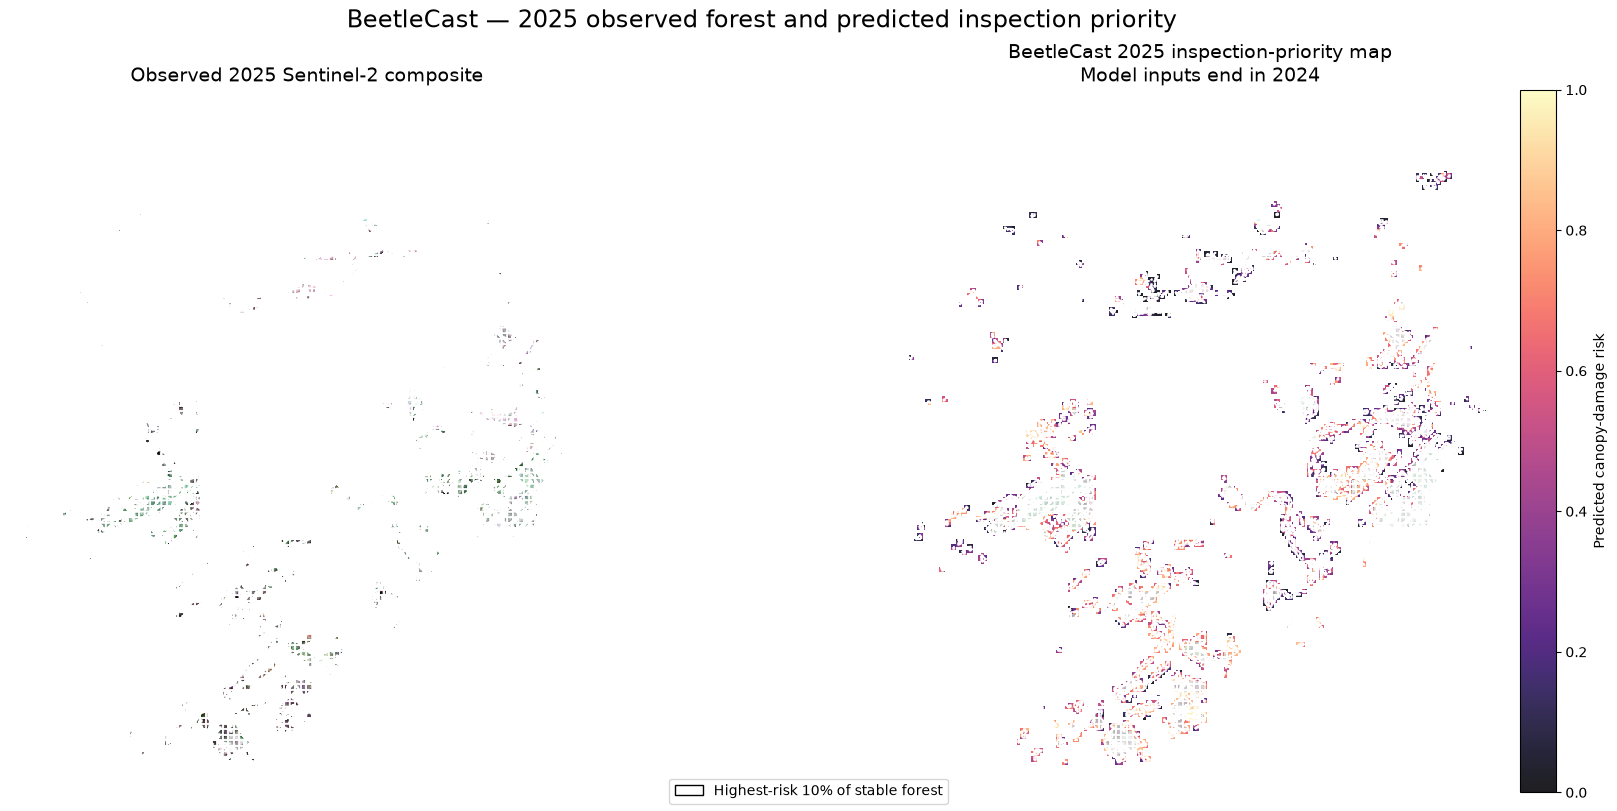

Saved: /Users/hemat/Desktop/hackathon-demo/outputs/deployment_2025/beetlecast_2025_prediction_vs_observed.png


In [13]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 8),
    constrained_layout=True,
)

axes[0].imshow(
    rgb_2025,
    extent=map_extent,
    origin="upper",
)
aoi_grid.boundary.plot(
    ax=axes[0],
    color="white",
    linewidth=1.1,
)
axes[0].set_title(
    "Observed 2025 Sentinel-2 composite",
    fontsize=14,
)
axes[0].axis("off")

axes[1].imshow(
    rgb_2025,
    extent=map_extent,
    origin="upper",
    alpha=0.38,
)

risk_image = axes[1].imshow(
    np.ma.masked_invalid(risk_grid),
    extent=map_extent,
    origin="upper",
    cmap="magma",
    vmin=0,
    vmax=1,
    alpha=0.88,
    interpolation="nearest",
)

patch_x = (
    left
    + (np.arange(patch_width) + 0.5)
    * dx
    * PATCH_PIXELS
)
patch_y = (
    top
    - (np.arange(patch_height) + 0.5)
    * dy
    * PATCH_PIXELS
)

if top_10_percent_mask.any():
    axes[1].contour(
        patch_x,
        patch_y,
        top_10_percent_mask.astype(int),
        levels=[0.5],
        colors="white",
        linewidths=0.7,
    )

aoi_grid.boundary.plot(
    ax=axes[1],
    color="white",
    linewidth=1.1,
)

legend_handles = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        label="Highest-risk 10% of stable forest",
    )
]

if labels_2025 is not None:
    labels_2025.boundary.plot(
        ax=axes[0],
        color="red",
        linewidth=1.5,
    )
    labels_2025.boundary.plot(
        ax=axes[1],
        color="cyan",
        linewidth=1.5,
    )

    legend_handles.append(
        mpatches.Patch(
            facecolor="none",
            edgecolor="cyan",
            label="Independent 2025 mapped damage",
        )
    )

axes[1].set_title(
    "BeetleCast 2025 inspection-priority map\n"
    "Model inputs end in 2024",
    fontsize=14,
)
axes[1].axis("off")

colorbar = fig.colorbar(
    risk_image,
    ax=axes[1],
    fraction=0.046,
    pad=0.03,
)
colorbar.set_label(
    "Predicted canopy-damage risk"
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(legend_handles),
    frameon=True,
)

fig.suptitle(
    "BeetleCast — 2025 observed forest and predicted inspection priority",
    fontsize=17,
)

comparison_path = (
    OUTPUT_ROOT
    / "beetlecast_2025_prediction_vs_observed.png"
)

plt.savefig(
    comparison_path,
    dpi=250,
    bbox_inches="tight",
)
plt.show()

print("Saved:", comparison_path)


## 13. Optional label-overlap check

This cell runs only if independent 2025 polygons were found.

It reports the share of mapped 2025 damage patches intersecting the highest-risk 10% of the eligible prediction area. This is **not** a full PR-AUC evaluation unless the 2025 survey coverage is known to be complete.


In [14]:
if labels_2025 is None:
    print(
        "Skipped: no independent 2025 labels are available."
    )
else:
    label_mask_2025 = rasterize(
        [
            (geometry, 1)
            for geometry in labels_2025.geometry
            if (
                geometry is not None
                and not geometry.is_empty
            )
        ],
        out_shape=(patch_height, patch_width),
        transform=patch_transform,
        fill=0,
        default_value=1,
        dtype="uint8",
        all_touched=True,
    ).astype(bool)

    comparable_damage = (
        label_mask_2025
        & eligible_mask
    )

    total_damage_patches = int(
        comparable_damage.sum()
    )

    captured_damage_patches = int(
        (
            comparable_damage
            & top_10_percent_mask
        ).sum()
    )

    if total_damage_patches == 0:
        print(
            "2025 labels do not overlap eligible stable-forest "
            "prediction patches."
        )
    else:
        capture = (
            captured_damage_patches
            / total_damage_patches
        )

        print("2025 visual overlap check")
        print("-------------------------")
        print(
            "Eligible mapped-damage patches:",
            total_damage_patches,
        )
        print(
            "Damage patches inside highest-risk 10%:",
            captured_damage_patches,
        )
        print(
            "Top-10% mapped-damage capture:",
            f"{capture:.1%}",
        )
        print()
        print(
            "Caution: this is a valid full-area metric only when "
            "2025 label coverage is complete and known."
        )


Skipped: no independent 2025 labels are available.


## 14. Deployment summary

In [15]:
print("BEETLECAST 2025 DEPLOYMENT COMPLETE")
print("-----------------------------------")
print(
    "Model: HistGradientBoostingClassifier"
)
print(
    "Training labels: supplied 2022–2023 mapped damage"
)
print(
    "2025 predictor cutoff: 2024"
)
print(
    "Sentinel-2 window: 2023 versus 2024"
)
print(
    "AlphaEarth history: 2018–2024"
)
print(
    "LULC stable-forest history: 2018–2024"
)
print(
    "Predicted stable-forest patches:",
    len(deployment),
)
print(
    "Independent 2025 labels:",
    "available" if labels_2025 is not None else "not available",
)
print()
print("Outputs:")
for path in sorted(OUTPUT_ROOT.iterdir()):
    print("-", path.name)


BEETLECAST 2025 DEPLOYMENT COMPLETE
-----------------------------------
Model: HistGradientBoostingClassifier
Training labels: supplied 2022–2023 mapped damage
2025 predictor cutoff: 2024
Sentinel-2 window: 2023 versus 2024
AlphaEarth history: 2018–2024
LULC stable-forest history: 2018–2024
Predicted stable-forest patches: 3041
Independent 2025 labels: not available

Outputs:
- beetlecast_2025_model.joblib
- beetlecast_2025_patch_predictions.csv
- beetlecast_2025_prediction_vs_observed.png
- beetlecast_2025_risk.tif
- beetlecast_2025_top10_inspection_patches.gpkg
